In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
# Input variables: 
# # bank client data: 
# 1 - age (numeric) 
# 2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student", 
# "blue-collar","self-employed","retired","technician","services") 
# 3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed) 
# 4 - education (categorical: "unknown","secondary","primary","tertiary") 
# 5 - default: has credit in default? (binary: "yes","no") 
# 6 - balance: average yearly balance, in euros (numeric) 
# 7 - housing: has housing loan? (binary: "yes","no") 
# 8 - loan: has personal loan? (binary: "yes","no")
# # related with the last contact of the current campaign:
# 9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
# 10 - day: last contact day of the month (numeric) 
# 11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec") 
# 12 - duration: last contact duration, in seconds (numeric) # # other attributes: 
# 13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact) 
# 14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted) 
# 15 - previous: number of contacts performed before this campaign and for this client (numeric) 
# 16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success") 
# Output variable (desired target): 
# 17 - y - has the client subscribed a term deposit? (binary: "yes","no")

## Missing Values

In [12]:
df.isnull().mean()

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
y            0.0
dtype: float64

In [14]:
df.shape

(45211, 17)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [18]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [20]:
df["pdays"]=df["pdays"].apply(lambda x:"non-contacted" if x==-1 else "contacted")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,non-contacted,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,non-contacted,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,non-contacted,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,non-contacted,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,non-contacted,0,unknown,no


In [22]:
cat_columns = df.dtypes[df.dtypes == "object"].index
cat_columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'pdays', 'poutcome', 'y'],
      dtype='object')

In [24]:
num_columns = df.dtypes[df.dtypes == "int64"].index
num_columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'previous'], dtype='object')

## EDA

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

### Univariate Analysis

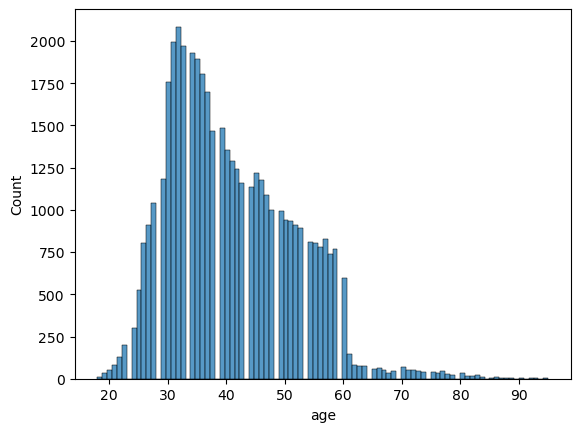

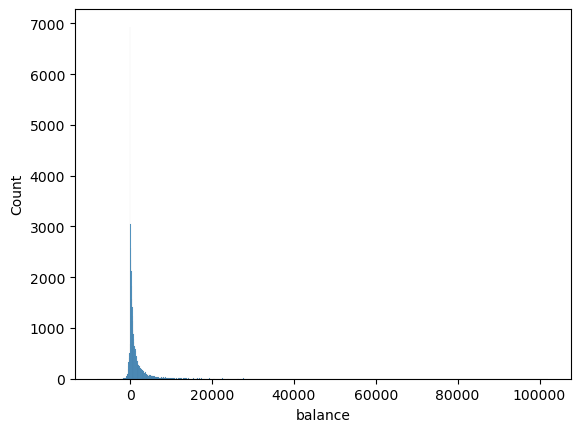

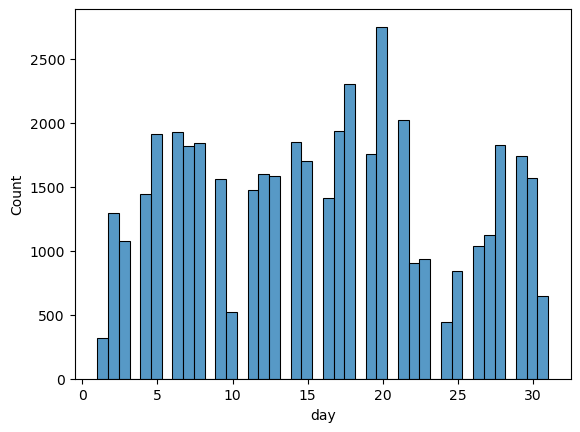

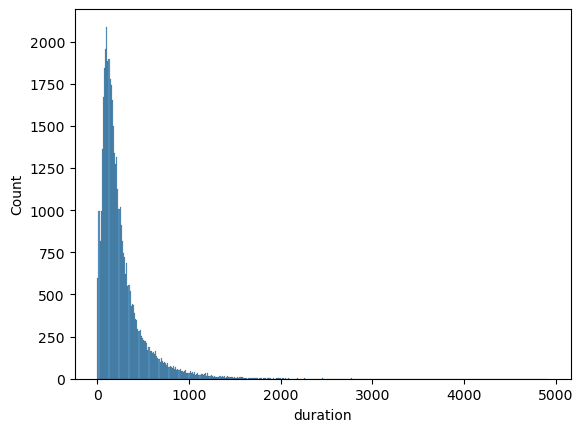

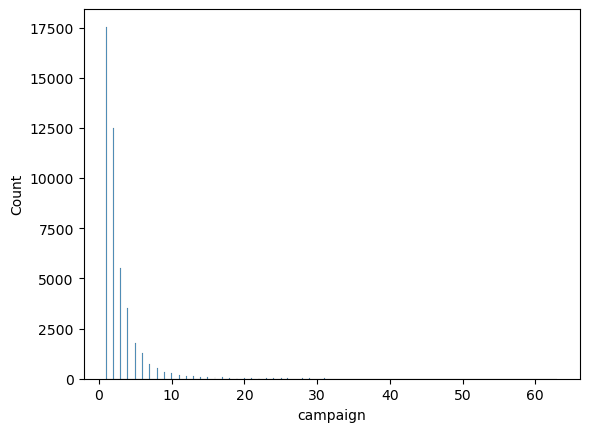

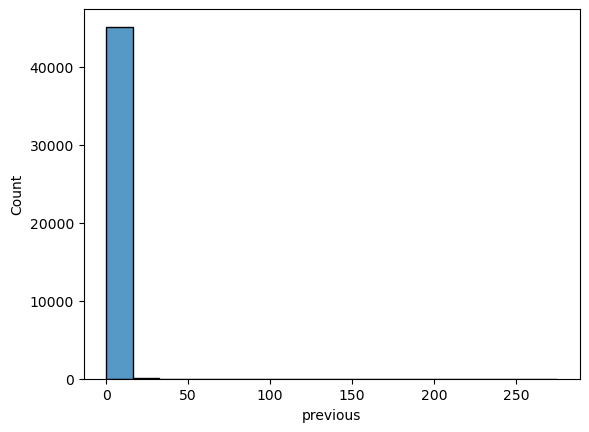

In [32]:
for col in num_columns:
    sns.histplot(x=df[col])
    plt.show()

In [59]:
sns.set_palette("cool")

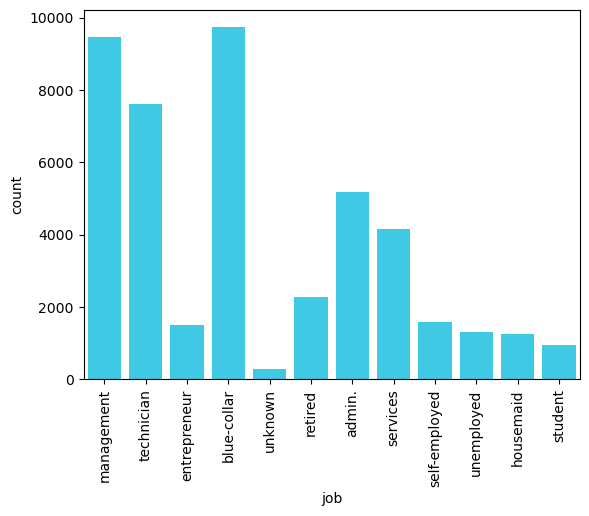

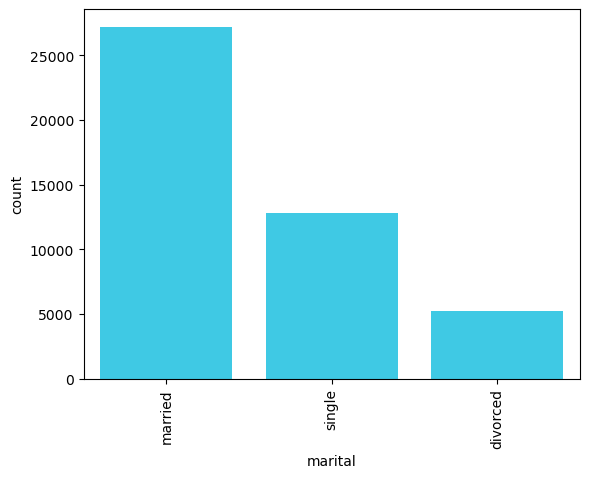

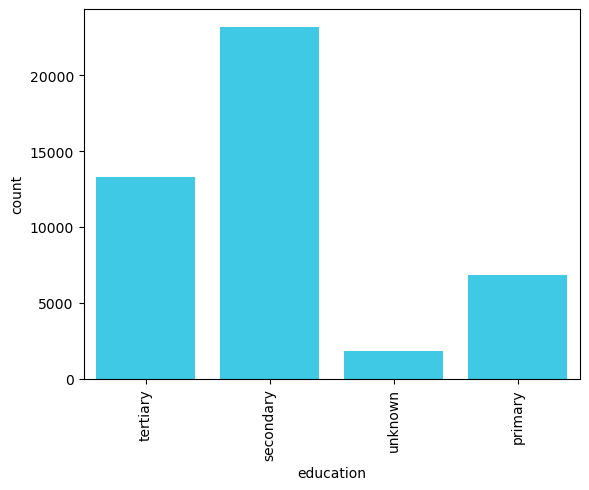

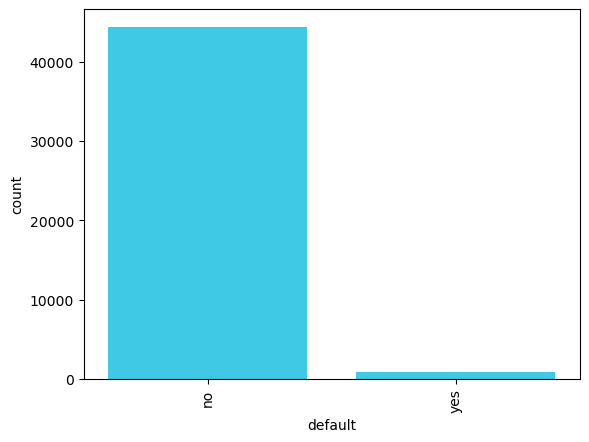

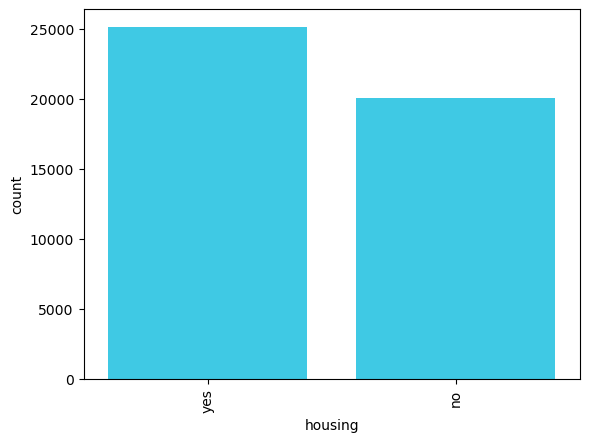

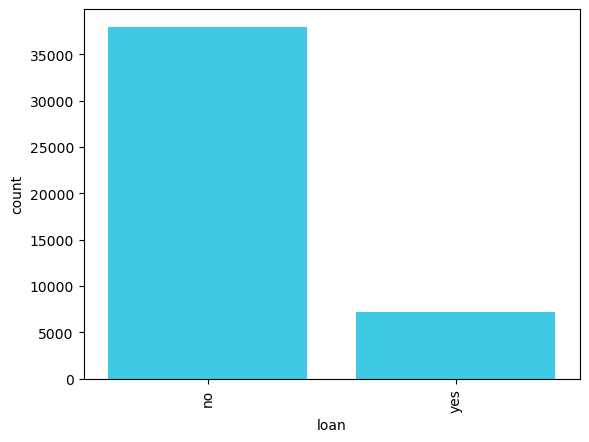

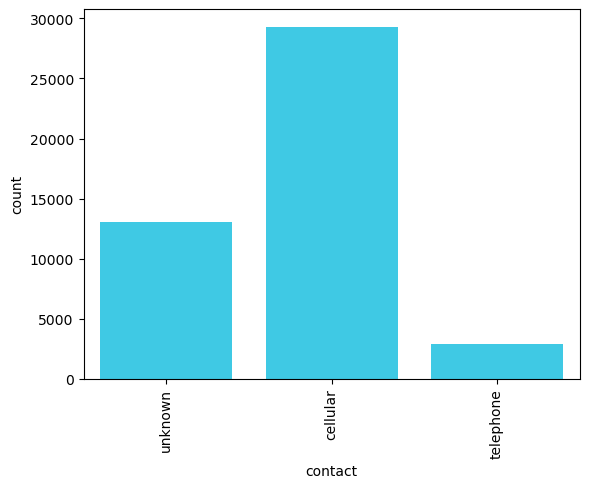

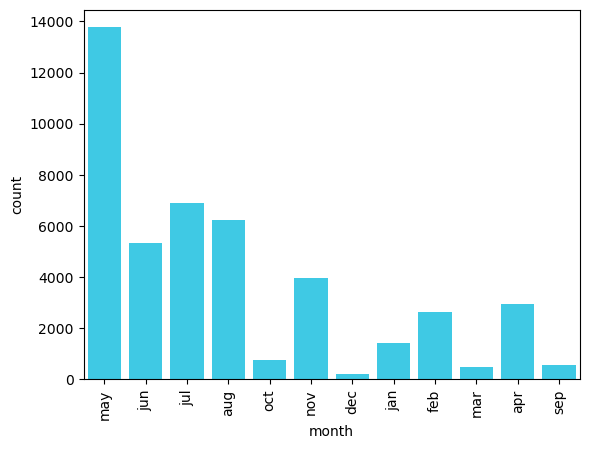

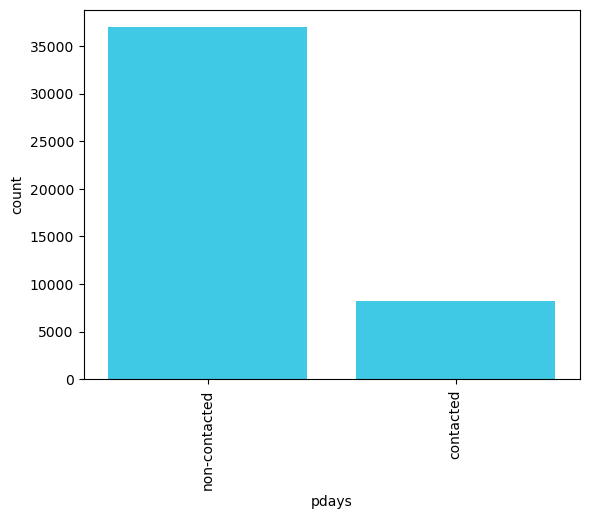

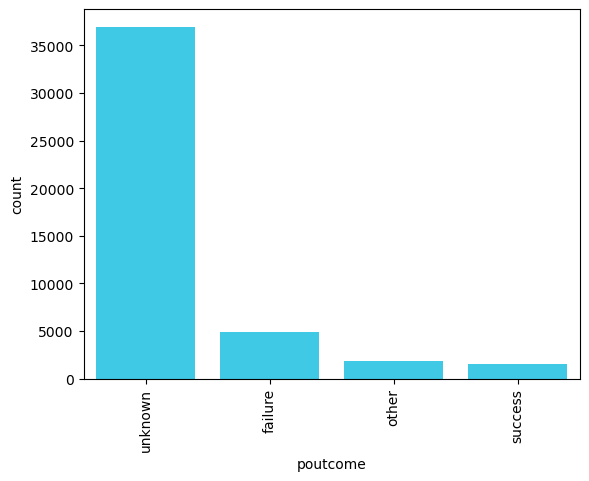

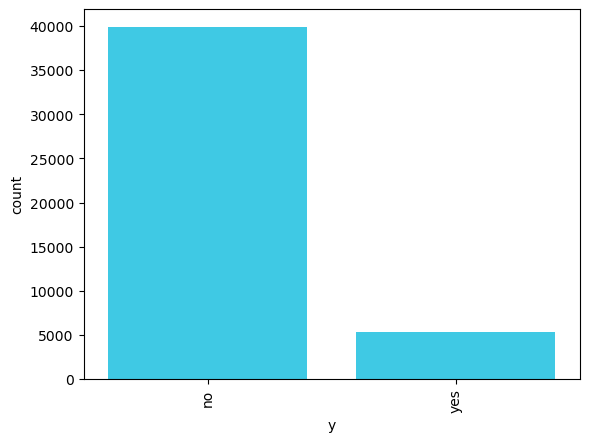

In [61]:
for col in cat_columns:
    sns.countplot(x=df[col])
    plt.xticks(rotation=90)
    plt.show()

### Bivariate Analysis

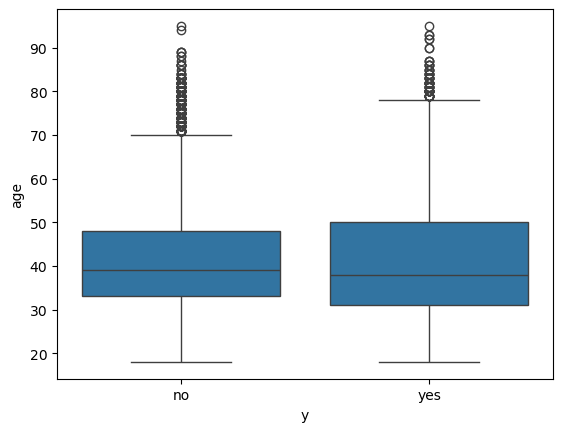

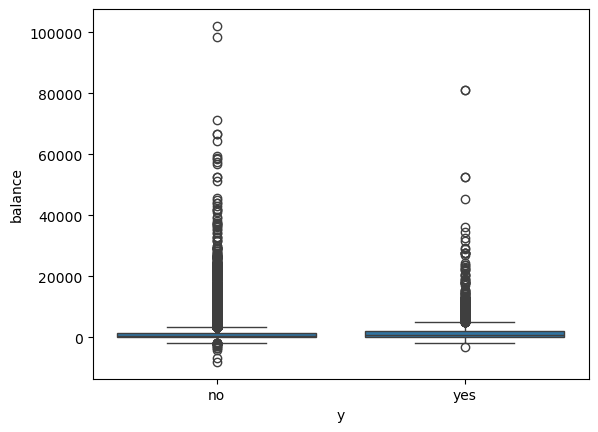

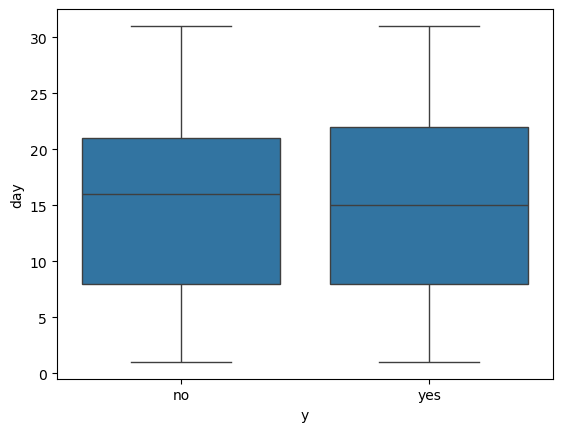

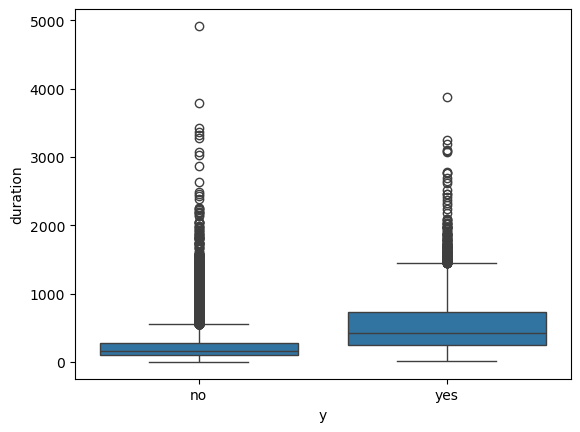

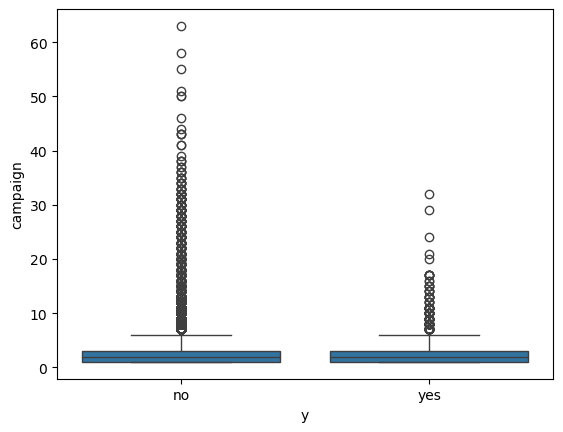

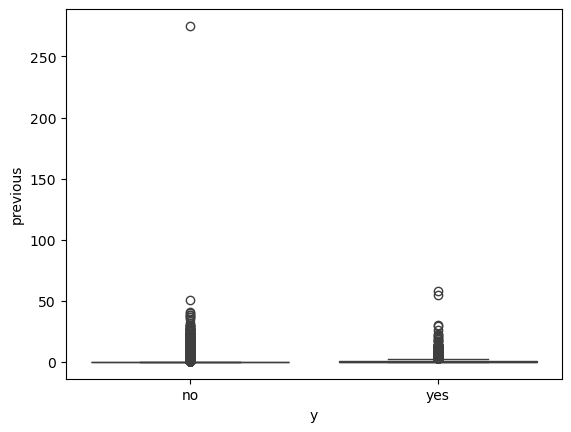

In [45]:
for col in num_columns:
    sns.boxplot(x=df["y"], y=df[col])
    plt.show()

### Multivariate Anlaysis

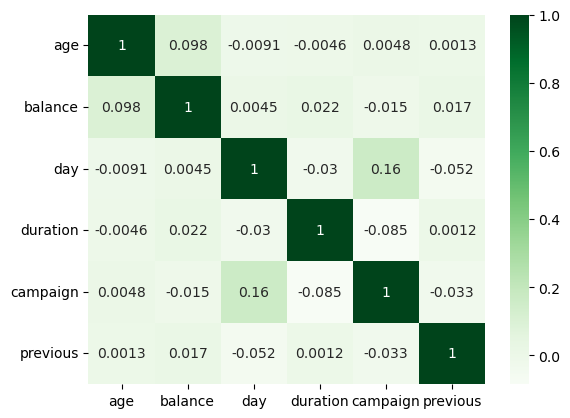

In [70]:
sns.heatmap(df[num_columns].corr(), annot=True, cmap="Greens")
plt.show()

## Data Preprocessing

### Key Points: 
- Scaling is not mandatory in tree models.
- Missing Value Imputation is not mandatory in tree models.
- Outlier Treatment is not mandatory in tree models.
- Dummy value creation is not required in tree models. 

In [74]:
df["y"] = df["y"].apply(lambda x: 1 if x == "yes" else 0)

In [76]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder

In [80]:
label_enc_cols = df.select_dtypes(include=["object"]).columns
label_encoder = LabelEncoder()
for col in label_enc_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [82]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,1,0,3,0


In [84]:
mapping = {category: index for index, category in enumerate(label_encoder.classes_)} 
print("Category to number mapping:", mapping)

Category to number mapping: {'failure': 0, 'other': 1, 'success': 2, 'unknown': 3}


In [86]:
X = df.drop(columns=["y"])
y = df["y"] 

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
print(X_train.shape, X_test.shape)

(36168, 16) (9043, 16)


In [104]:
pip install xgboost

  Using cached xgboost-2.1.2-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.2-py3-none-macosx_12_0_arm64.whl (1.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [106]:
from xgboost import XGBClassifier

In [110]:
xgb_model = XGBClassifier()

In [112]:
%%time
xgb_model.fit(X_train, y_train)

CPU times: user 690 ms, sys: 300 ms, total: 990 ms
Wall time: 120 ms


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [114]:
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

In [116]:
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f'Initial Model Train Accuracy: {train_accuracy}') 
print(f'Initial Model Test Accuracy: {test_accuracy}')

Initial Model Train Accuracy: 0.9533012607830126
Initial Model Test Accuracy: 0.9052305650779608


In [118]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()

In [120]:
%%time
dt_model.fit(X_train, y_train)

y_pred_train = dt_model.predict(X_train)
y_pred_test = dt_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f'Initial Model Train Accuracy: {train_accuracy}') 
print(f'Initial Model Test Accuracy: {test_accuracy}')

Initial Model Train Accuracy: 1.0
Initial Model Test Accuracy: 0.8696229127501935
CPU times: user 144 ms, sys: 4.74 ms, total: 149 ms
Wall time: 147 ms


## Hyperparameter Tuning

In [123]:
from sklearn.model_selection import GridSearchCV

In [125]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

In [127]:
xgb_model = XGBClassifier()

In [129]:
%%time
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f'Best Parameters: {best_params}, Best Score: {best_score}')


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.6}, Best Score: 0.9062430878124309
CPU times: user 1.19 s, sys: 1.08 s, total: 2.28 s
Wall time: 6.51 s


In [131]:
from sklearn.ensemble import GradientBoostingClassifier
gbm_model = GradientBoostingClassifier()

In [133]:
%%time
grid_search = GridSearchCV(estimator=gbm_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f'Best Parameters: {best_params}, Best Score: {best_score}')

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}, Best Score: 0.9067684140676842
CPU times: user 7.74 s, sys: 914 ms, total: 8.65 s
Wall time: 1min 37s


In [137]:
from sklearn.ensemble import AdaBoostClassifier
adm_model = AdaBoostClassifier()

In [145]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2]
}

In [147]:
%%time
grid_search = GridSearchCV(estimator=adm_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f'Best Parameters: {best_params}, Best Score: {best_score}')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

Best Parameters: {'learning_rate': 0.2, 'n_estimators': 200}, Best Score: 0.8981696527316965
CPU times: user 2.3 s, sys: 207 ms, total: 2.51 s
Wall time: 7.82 s
